Milestone 3: Neural Network Designs

In [1]:
import tensorflow as tf
from sklearn.pipeline import Pipeline
from scikeras.wrappers import KerasClassifier
from pathlib import Path
from time import strftime
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10,
                                                     restore_best_weights=True)

def get_run_logdir(root_logdir='my_logs'):
    return Path(root_logdir)/strftime("run_%Y_%m_%d_%H_%M_%S")

run_logdir = get_run_logdir()

tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir,
                                                profile_batch=(100, 200))


def create_baseline(meta):
    X_shape_ = meta["X_shape_"]
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(300, activation="relu", input_shape=(X_shape_[1],)),
        tf.keras.layers.Dense(300, activation="relu"),
        tf.keras.layers.Dense(4, activation="softmax")
    ])
    model.compile(optimizer="adam", 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])
    return model


c:\Users\samue\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
clf = KerasClassifier(model=create_baseline, epochs=50, batch_size=32, verbose=1)

In [3]:
import numpy as np
from sklearn.svm import LinearSVC
data = np.load('octmnist.npz')
print("Keys in octmnist.npz: ", data.files)

for k in data.files:
    arr = data[k]
    print(f"{k:>12}: shape = {arr.shape}")

Keys in octmnist.npz:  ['train_images', 'val_images', 'test_images', 'train_labels', 'val_labels', 'test_labels']
train_images: shape = (97477, 28, 28)
  val_images: shape = (10832, 28, 28)
 test_images: shape = (1000, 28, 28)
train_labels: shape = (97477, 1)
  val_labels: shape = (10832, 1)
 test_labels: shape = (1000, 1)


In [4]:
train_images = data["train_images"]
train_labels = data["train_labels"].ravel()

val_images = data["val_images"]
val_labels = data["val_labels"].ravel()

test_images = data["test_images"]
test_labels = data["test_labels"].ravel()

In [5]:
from utils import flattener
from sklearn.preprocessing import MinMaxScaler

pipe_baseline = Pipeline([
    ("Flatten", flattener),
    ("Scale", MinMaxScaler()),
    ("model", clf)
])

In [6]:
from utils import train_eval_model
from utils import stratified_subset

x_tr, y_tr = stratified_subset(train_images, train_labels, 22000)
x_va, y_va = stratified_subset(val_images, val_labels, 2000)

acc_baseline, prec_baseline, recall_baseline = train_eval_model(
    name="Baseline ANN",
    model=pipe_baseline,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)

c:\Users\samue\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5799 - loss: 1.0345
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6380 - loss: 0.9370
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6671 - loss: 0.8763
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6931 - loss: 0.8243
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7078 - loss: 0.7801
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7277 - loss: 0.7392
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7391 - loss: 0.7129
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7470 - loss: 0.6853
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7570 - loss: 0.6637
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7627 - loss: 0.6442
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7695 - loss: 0.6276
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

To absolutely no ones suprise even the completely untuned most baseline neural network possible sort of destroyed all other models.

In [7]:
from utils import median, avg_2x2_pool, flatten_data
from sklearn.preprocessing import FunctionTransformer

preprocess_nn = Pipeline([
    ("median", FunctionTransformer(median)),
    ("avg", FunctionTransformer(avg_2x2_pool)),
    ("flat", FunctionTransformer(flatten_data)),
    ("scale", MinMaxScaler()),
    ("model", clf)
])

acc_prep, prec_prep, recall_prep = train_eval_model(
    name="avg+median filtering results",
    model=preprocess_nn,
    x_tr=x_tr,
    x_va=x_va,
    y_tr=y_tr,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)

Epoch 1/50


c:\Users\samue\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5717 - loss: 1.0484
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6330 - loss: 0.9430
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6543 - loss: 0.9056
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6719 - loss: 0.8684
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6831 - loss: 0.8464
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6934 - loss: 0.8200
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6990 - loss: 0.8050
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7096 - loss: 0.7858
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7147 - loss: 0.7715
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7171 - loss: 0.7624
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7244 - loss: 0.7458
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy

Performed Worse than on just the raw training data.

In [8]:
avg_nn = Pipeline([
    ("avg14", FunctionTransformer(avg_2x2_pool)),
    ("flat", FunctionTransformer(flatten_data)),
    ("scale", MinMaxScaler()),
    ("model", clf)
])


acc_avc, prec_avg, recall_avg = train_eval_model(
    name="avg filtering results",
    model=avg_nn,
    x_tr=x_tr,
    x_va=x_va,
    y_tr=y_tr,
    y_va=y_va,
    callbacks=[tensorboard_cb, early_stopping_cb]
)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)

Epoch 1/50


c:\Users\samue\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5790 - loss: 1.0375
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6402 - loss: 0.9337
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6619 - loss: 0.8856
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6787 - loss: 0.8455
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6991 - loss: 0.8062
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7062 - loss: 0.7846
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7164 - loss: 0.7594
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7282 - loss: 0.7346
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7313 - loss: 0.7204
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7376 - loss: 0.7080
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7468 - loss: 0.6902
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy

Once again overall a worse performance. Preprocessing appears to be a possible detriment for this.

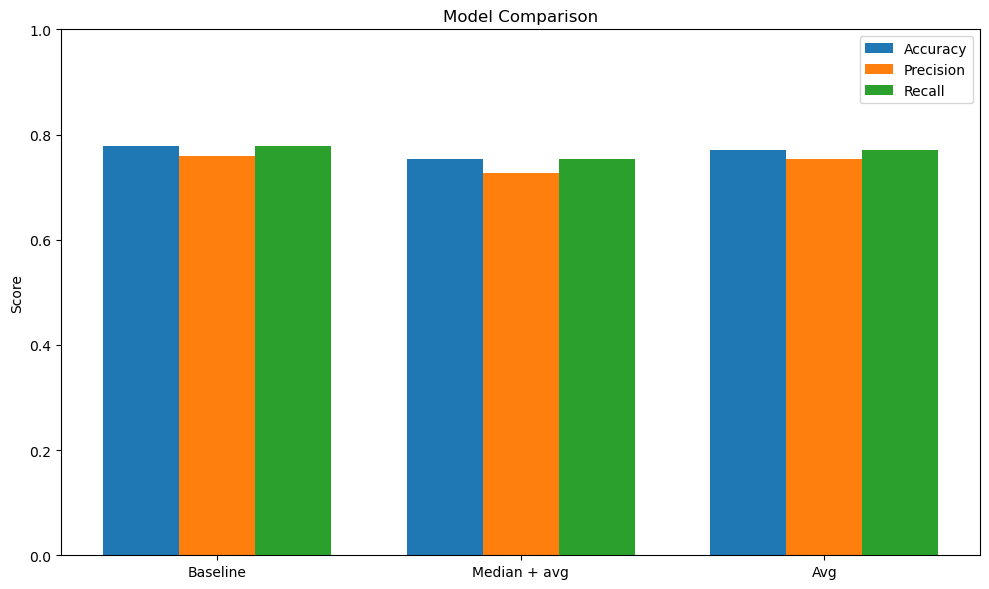

In [9]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Baseline", "Median + avg", "Avg"]
accuracy =  [acc_baseline, acc_prep, acc_avc]  # replace with your values
precision = [prec_baseline, prec_prep, prec_avg]
recall =    [recall_baseline, recall_prep, recall_avg]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, accuracy, width, label="Accuracy")
ax.bar(x, precision, width, label="Precision")
ax.bar(x + width, recall, width, label="Recall")

ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

All perfrom roughly similar with a slight edge to no preprocessing at this moment.

In [10]:
label_names = {
    0: "Normal",
    1: "Choroidal neovascularization",
    2: "Diabetic macular edema",
    3: "Drusen"
}



In [11]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_tr)

Now lets test results on a wide and deep network. The goal of a wide and deep network is to both hopefully learn simple patterns that can be learned just from the input data. As well as complex patterns that can be learned from the deep path too.

In [12]:
def create_wide_and_deep(meta):
    '''Creates the wide & deep network.
    deep network is designed to be same as pervious networks
    so we can guage if the width actually adds anything to the network.
    '''
    X_shape = meta["X_shape_"]
    print(X_shape)

    inputs= tf.keras.layers.Input(shape=(X_shape[1],))

    hidden_layer_1 = tf.keras.layers.Dense(300, activation='relu')(inputs)
    hidden_layer_2 = tf.keras.layers.Dense(300, activation='relu')(hidden_layer_1)

    concat_layer = tf.keras.layers.Concatenate()([inputs, hidden_layer_2])
    output_layer = tf.keras.layers.Dense(4, activation="softmax")(concat_layer)

    
    model = tf.keras.Model(inputs=inputs, outputs=output_layer)

    model.compile(optimizer="adam", 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])
    return model

clf_wide = KerasClassifier(model=create_wide_and_deep, epochs=50, batch_size=32, verbose=1)

pipe_baseline_wide = Pipeline([
    ("Flatten", FunctionTransformer(flatten_data)),
    ("Scale", MinMaxScaler()),
    ("model", clf_wide)
])

In [13]:
train_eval_model(
    name="Wide & Deep baseline model",
    model=pipe_baseline_wide,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)

(22000, 784)
Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5762 - loss: 1.0506
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6434 - loss: 0.9309
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6723 - loss: 0.8722
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6939 - loss: 0.8173
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7101 - loss: 0.7744
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7258 - loss: 0.7362
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7389 - loss: 0.7047
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7485 - loss: 0.6854
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7595 - loss: 0.6594
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7657 - loss: 0.6420
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7739 - loss: 0.6252
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━

(0.78, 0.7708492201706331, 0.78)

Very consistent results but nothing incredible.

In [14]:
pipe_avg_wide = Pipeline([
    ("avg", FunctionTransformer(avg_2x2_pool)),
    ("Flatten", FunctionTransformer(flatten_data)),
    ("Scale", MinMaxScaler()),
    ("model", clf_wide)
])

train_eval_model(
    name="Wide & Deep baseline model",
    model=pipe_avg_wide,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)


(22000, 196)
Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5805 - loss: 1.0352
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6397 - loss: 0.9311
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6697 - loss: 0.8756
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6844 - loss: 0.8396
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6993 - loss: 0.8041
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7125 - loss: 0.7722
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7208 - loss: 0.7499
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7284 - loss: 0.7339
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7370 - loss: 0.7133
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7435 - loss: 0.6935
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7492 - loss: 0.6793
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━

(0.7835, 0.7603010312216563, 0.7835)

Best Accuracy So Far, but lower precision

In [15]:
pipe_med_avg_wide = Pipeline([
    ("med", FunctionTransformer(median)),
    ("avg", FunctionTransformer(avg_2x2_pool)),
    ("Flatten", FunctionTransformer(flatten_data)),
    ("Scale", MinMaxScaler()),
    ("model", clf_wide)
])

train_eval_model(
    name="Wide & Deep Median + Avg model",
    model=pipe_med_avg_wide,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)

(22000, 196)
Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5798 - loss: 1.0440
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6320 - loss: 0.9469
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6536 - loss: 0.9067
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6684 - loss: 0.8735
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6785 - loss: 0.8483
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6891 - loss: 0.8251
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6976 - loss: 0.8070
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7065 - loss: 0.7912
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7071 - loss: 0.7800
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7165 - loss: 0.7650
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7220 - loss: 0.7464
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━

(0.757, 0.7293605314125037, 0.757)

In [16]:
def create_wide_and_deep_subsample(meta, wide_frac=0.5, deep_frac=0.5, seed=42):
    X_shape_ = meta["X_shape_"]
    n_features = X_shape_[1]

    rng = np.random.RandomState(seed)
    wide_idx = rng.choice(n_features, size=int(n_features * wide_frac), replace=False)
    deep_idx = rng.choice(n_features, size=int(n_features * deep_frac), replace=False)

    inputs = tf.keras.layers.Input(shape=(n_features,))

    wide_input = tf.keras.layers.Lambda(lambda x: tf.gather(x, wide_idx, axis=1))(inputs)
    deep_input = tf.keras.layers.Lambda(lambda x: tf.gather(x, deep_idx, axis=1))(inputs)

    # Deep path
    deep = tf.keras.layers.Dense(300, activation="relu")(deep_input)
    deep = tf.keras.layers.Dense(300, activation="relu")(deep)

    # Concatenate
    concat = tf.keras.layers.Concatenate()([wide_input, deep])

    output = tf.keras.layers.Dense(4, activation="softmax")(concat)

    model = tf.keras.Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"]
    )
    return model

clf_wide_subsample = KerasClassifier(model=create_wide_and_deep_subsample, epochs=50, batch_size=32, verbose=1)

pipe_wide_subsample_base = Pipeline([
    ("flat", flattener),
    ("scale", MinMaxScaler()),
    ("model", clf_wide_subsample)
])

train_eval_model(
    name="Wide & Deep with feature subsampling",
    model=pipe_wide_subsample_base,
    x_tr=x_tr,
    x_va=x_va,
    y_tr=y_tr,
    y_va=y_va,
    callbacks=[early_stopping_cb, tensorboard_cb]
)


Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5796 - loss: 1.0399
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6437 - loss: 0.9284
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6718 - loss: 0.8682
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6969 - loss: 0.8102
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7175 - loss: 0.7683
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7326 - loss: 0.7287
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7433 - loss: 0.7014
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7531 - loss: 0.6733
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7596 - loss: 0.6557
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7659 - loss: 0.6375
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7741 - loss: 0.6196
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/ste

(0.769, 0.7530852390774496, 0.769)

The wide and deep model performed slightly better than the baseline model. Interestingly there seems to be a percision recall trade off between averaging for this case. When averaging to reduce dimensionality the precision dropped but the recall increased. I would interpret this as the model sort of being more 'certain' or 'aggressive' in it's guessing leading to more total positive cases captured on average per class but also less overall accuracy on those guesses. Ultimately we should take both these into consideration especially when acknowledging that our models are tuned for Accuracy (Marco Recall).

Let us now look towards tuning an existing model and observe the results there. First we will explore general ideas in model architecture. Number of layers, number of neurons, learning rate, and basic optimimizer choices. This can help us get more insight into what kind of model architectures are doing well for this problem.

In [26]:
import keras_tuner as kt

def build_tuned_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")

    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    avg = hp.Choice("avg", values=[True, False])
    pool = hp.Int("pool_size", min_value=2, max_value=4)
    activation = hp.Choice("activation", values=["relu", "leaky_relu", "elu", "selu"])
    batch_norm = hp.Choice("batch_norm", values=[True, False])
    decay_rate = hp.Float("decay_rate", min_value=0.9, max_value=0.99, step=0.01)

    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=learning_rate,
                decay_steps=100,
                decay_rate=decay_rate,
            )
        )
    else:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=learning_rate,
                decay_steps=100,
                decay_rate=decay_rate,
            )
        )

    model = tf.keras.Sequential()

    if avg:
        model.add(tf.keras.layers.Reshape((28, 28, 1))) #Added because 4d data is expected for average pooling
        model.add(tf.keras.layers.AveragePooling2D(pool_size=(pool, pool)))

    model.add(tf.keras.layers.Rescaling(scale=1.0 / 255)) #Our MinMaxScaler in tensorflow format

    model.add(tf.keras.layers.Flatten())

    dropout_rate = hp.Float("dropout", min_value=0.0, max_value=0.5, step=0.1)

    for i in range(n_hidden):
        n_neurons = hp.Int(f"n_neurons{i}", min_value=16, max_value=256)
        model.add(tf.keras.layers.Dense(n_neurons, activation=activation))
        if batch_norm:
            model.add(tf.keras.layers.BatchNormalization())
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(4, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

This is a pretty deep tuning search. so lets break it down.
1. This allows us first and formost give a general idea of what model architecture is preferred (deep path vs shallow, wide layers vs small layers)
2. Control our preprocessing step through the averaging choice.
3. Have a preliminary search over activation functions & optimizers
4. Introduce batch normalization & dropout rate if it is beneficial.

In [27]:
tuner = kt.RandomSearch(
    build_tuned_model,
    objective="val_accuracy",
    max_trials=50,
    directory="tuning_results",
    project_name="my_rnd_search",
)

tuner.search(
    x_tr, y_tr,
    epochs=50,
    validation_data=(x_va, y_va),
    callbacks=[
        early_stopping_cb,
        tensorboard_cb
    ]
)

Trial 50 Complete [00h 00m 49s]
val_accuracy: 0.49300000071525574

Best val_accuracy So Far: 0.7944999933242798
Total elapsed time: 15h 11m 10s
